# Tier 1 powertrain component verification

Interactive checks of the six standalone symbolic powertrain components and the
explicit series-hybrid coupling example:

| Component | Module |
|---|---|
| `Motor`, `SimpleMotorLossModel` | `powertrain/components/motor.py` |
| `Generator` | `powertrain/components/generator.py` |
| `Battery` | `powertrain/components/battery.py` |
| `SimpleTurboshaft` | `powertrain/components/turboshaft.py` |
| `Gearbox` | `powertrain/components/gearbox.py` |
| `ActuatorDiskPropulsor` | `powertrain/components/propulsor.py` |

Each section covers closed-form identities, limiting cases, physical trends and
sign conventions, then the notebook checks AeroSandbox/CasADi symbolic
compatibility and the coupled `asb.Opti` reference point. Every `check(...)` is
recorded and summarized at the end; the final cell also runs the unittest suite.
Repository, environment and governance checks (Tier 0) live in
`notebooks/tier0_foundation/foundation_verification.ipynb`.

All defaults are illustrative, not Archer specifications.

Run from the repo root environment:

```powershell
uv sync --group notebooks
uv run jupyter lab notebooks/tier1_powertrain_components
```

In [1]:
import sys
from pathlib import Path

# Make `examples` importable alongside the installed package.
repo_root = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / "pyproject.toml").exists())
if str(repo_root) not in sys.path:
    sys.path.insert(0, str(repo_root))

import aerosandbox as asb
import aerosandbox.numpy as np
import casadi as cas
import matplotlib.pyplot as plt
from aerosandbox.library.propulsion_propeller import propeller_shaft_power_from_thrust

from aircraft_closure.powertrain.components.motor import Motor, SimpleMotorLossModel
from aircraft_closure.powertrain.components.generator import Generator
from aircraft_closure.powertrain.components.battery import Battery
from aircraft_closure.powertrain.components.turboshaft import SimpleTurboshaft
from aircraft_closure.powertrain.components.gearbox import Gearbox
from aircraft_closure.powertrain.components.propulsor import ActuatorDiskPropulsor
from examples.series_hybrid_point_explicit import solve_reference_point

plt.rcParams.update({"figure.figsize": (7, 4), "axes.grid": True})

check_log = []

def check(name, condition):
    passed = bool(condition)
    check_log.append((name, passed))
    print(f"[{'PASS' if passed else 'FAIL'}] {name}")

def close(a, b, rel=1e-9, abs_=1e-9):
    return np.all(np.abs(np.asarray(a) - np.asarray(b)) <= abs_ + rel * np.abs(np.asarray(b)))

## 1. Motor

Motoring quadrant only. Shaft power is $P_s = \omega\,Q$; the simple loss model is
$P_{loss} = k_Q Q^2 + k_\omega \omega^2$; electrical input is $P_e = P_s + P_{loss}$
and current is $I = P_e / V$.

In [2]:
motor = Motor()
r = motor.evaluate(400, 200, 800)
print(r)
print(f"efficiency = {r.power_shaft_W / r.power_electric_W:.4f}")

check("motor: P_shaft = speed * torque", r.power_shaft_W == 400 * 200)
check("motor: P_elec = P_shaft + P_loss", close(r.power_electric_W, r.power_shaft_W + r.power_loss_W))
check("motor: I * V = P_elec", close(r.current_A * 800, r.power_electric_W))
check("motor: losses > 0", r.power_loss_W > 0)
check("motor: lossless model gives P_elec = P_shaft",
      Motor(loss_model=SimpleMotorLossModel(0, 0)).evaluate(400, 200, 800).power_electric_W == 80000)
check("motor: zero demand -> zero electrical power", Motor().evaluate(0, 0, 800).power_electric_W == 0)
check("motor: halving voltage doubles current",
      close(Motor().evaluate(400, 200, 400).current_A, 2 * r.current_A))
check("motor: mass = rated power / specific power", motor.get_mass() == 100000 / 5000)

MotorResult(power_shaft_W=80000, power_electric_W=80960.0, current_A=101.2, power_loss_W=960.0)
efficiency = 0.9881
[PASS] motor: P_shaft = speed * torque
[PASS] motor: P_elec = P_shaft + P_loss
[PASS] motor: I * V = P_elec
[PASS] motor: losses > 0
[PASS] motor: lossless model gives P_elec = P_shaft
[PASS] motor: zero demand -> zero electrical power
[PASS] motor: halving voltage doubles current
[PASS] motor: mass = rated power / specific power


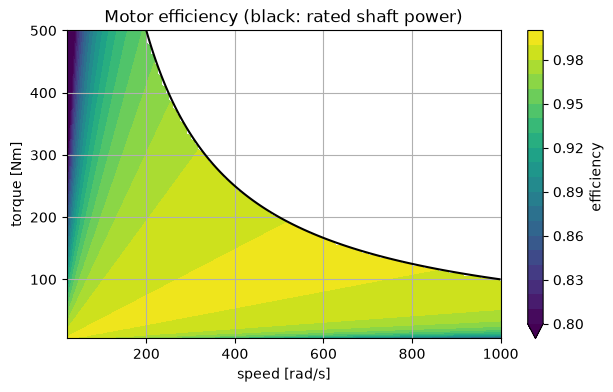

[PASS] motor: minimum loss at fixed power where torque and speed losses balance


In [3]:
# Efficiency map over the motoring envelope (numeric arrays pass straight through).
speed_rad_s, torque_Nm = np.meshgrid(np.linspace(20, motor.max_speed_rad_s, 120),
                                     np.linspace(5, motor.max_torque_Nm, 120))
grid = motor.evaluate(speed_rad_s, torque_Nm, 800)
efficiency = grid.power_shaft_W / grid.power_electric_W
in_rating = grid.power_shaft_W <= motor.power_rated_W

fig, ax = plt.subplots()
cs = ax.contourf(speed_rad_s, torque_Nm, np.where(in_rating, efficiency, np.nan),
                 levels=np.linspace(0.80, 1.0, 21), cmap="viridis", extend="min")
ax.contour(speed_rad_s, torque_Nm, grid.power_shaft_W, levels=[motor.power_rated_W], colors="k")
fig.colorbar(cs, label="efficiency")
ax.set(xlabel="speed [rad/s]", ylabel="torque [Nm]",
       title="Motor efficiency (black: rated shaft power)")
plt.show()

# With k_Q Q^2 + k_w w^2 losses at fixed power, peak efficiency is where the two terms are equal.
k = motor.loss_model
power_W = 50000
speed_opt_rad_s = (k.torque_loss_W_Nm2 * power_W**2 / k.speed_loss_W_s2_rad2) ** 0.25
speeds = np.linspace(100, 1000, 2001)
loss_W = Motor().evaluate(speeds, power_W / speeds, 800).power_loss_W
check("motor: minimum loss at fixed power where torque and speed losses balance",
      abs(speeds[np.argmin(loss_W)] - speed_opt_rad_s) < 1.0)

## 2. Generator

Generating quadrant: shaft input supplies electrical output plus losses,
$P_e = P_s - P_{loss}$. Current is positive *out of* the machine. Shares the
motor loss model and `MotorLimits`.

GeneratorResult(power_shaft_W=80000, power_electric_W=79040.0, current_A=98.8, power_loss_W=960.0)
[PASS] generator: P_shaft = P_elec + P_loss
[PASS] generator: output current positive
[PASS] generator: I * V = P_elec
[PASS] generator: zero shaft -> zero output
[PASS] generator: more torque -> more output
[PASS] motor/generator: same loss at same operating point
[PASS] generator: mass = rated power / specific power


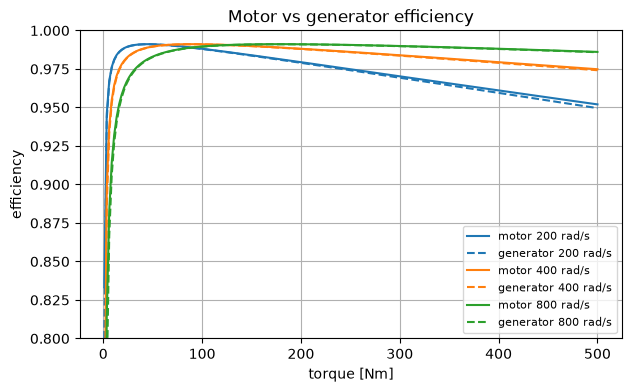

In [4]:
generator = Generator()
g = generator.evaluate(400, 200, 800)
print(g)

check("generator: P_shaft = P_elec + P_loss", close(g.power_shaft_W, g.power_electric_W + g.power_loss_W))
check("generator: output current positive", g.current_A > 0)
check("generator: I * V = P_elec", close(g.current_A * 800, g.power_electric_W))
check("generator: zero shaft -> zero output", Generator().evaluate(0, 0, 800).power_electric_W == 0)
check("generator: more torque -> more output",
      Generator().evaluate(400, 200, 800).power_electric_W > Generator().evaluate(400, 100, 800).power_electric_W)
check("motor/generator: same loss at same operating point",
      close(g.power_loss_W, Motor().evaluate(400, 200, 800).power_loss_W))
check("generator: mass = rated power / specific power", generator.get_mass() == 100000 / 4000)

torque = np.linspace(1, 500, 200)
fig, ax = plt.subplots()
for speed in (200, 400, 800):
    res_m = Motor().evaluate(speed, torque, 800)
    res_g = Generator().evaluate(speed, torque, 800)
    line, = ax.plot(torque, res_m.power_shaft_W / res_m.power_electric_W, label=f"motor {speed} rad/s")
    ax.plot(torque, res_g.power_electric_W / res_g.power_shaft_W, "--", color=line.get_color(),
            label=f"generator {speed} rad/s")
ax.set(xlabel="torque [Nm]", ylabel="efficiency", ylim=(0.8, 1.0), title="Motor vs generator efficiency")
ax.legend(fontsize=8)
plt.show()

## 3. Battery

Constant OCV + series resistance. Positive current discharges.
$V = V_{oc} - I R$, $P_{chem} = V_{oc} I = P_e + I^2 R$,
$\text{SOC}_{next} = \text{SOC} - P_{chem}\,\Delta t / E$. No SOC clamping inside the model.
Mass is the larger of the energy-sized and power-sized pack.

In [5]:
battery = Battery()
b = battery.evaluate(100, 0.9, 60)
print(b)

check("battery: terminal voltage = V_oc - I R", b.voltage_V == 800 - 100 * 0.05)
check("battery: P_chem = P_elec + P_loss", close(b.power_chemical_W, b.power_electric_W + b.power_loss_W))
check("battery: SOC drop matches chemical energy",
      close((0.9 - b.soc_next) * battery.energy_capacity_J, b.power_chemical_W * 60))
c = battery.evaluate(-100, 0.5, 60)
check("battery: charging -> negative terminal power, SOC rises, loss still positive",
      c.power_electric_W < 0 and c.soc_next > 0.5 and c.power_loss_W > 0)
z = battery.evaluate(0, 0.5, 60)
check("battery: zero current -> OCV, no loss, SOC unchanged",
      z.voltage_V == 800 and z.power_loss_W == 0 and z.soc_next == 0.5)
check("battery: no hidden SOC clamping", battery.evaluate(100, 0.2, 1000).soc_next < battery.min_soc)
ideal = Battery(resistance_ohm=0).evaluate(10000 / 800, 0.9, 360)
check("battery: ideal 10 kW for 360 s uses 0.1 SOC of 36 MJ", close(ideal.soc_next, 0.8))

BatteryResult(voltage_V=795.0, current_A=100, power_electric_W=79500.0, power_loss_W=500.0, power_chemical_W=80000.0, soc_next=0.7666666666666667)
[PASS] battery: terminal voltage = V_oc - I R
[PASS] battery: P_chem = P_elec + P_loss
[PASS] battery: SOC drop matches chemical energy
[PASS] battery: charging -> negative terminal power, SOC rises, loss still positive
[PASS] battery: zero current -> OCV, no loss, SOC unchanged
[PASS] battery: no hidden SOC clamping
[PASS] battery: ideal 10 kW for 360 s uses 0.1 SOC of 36 MJ


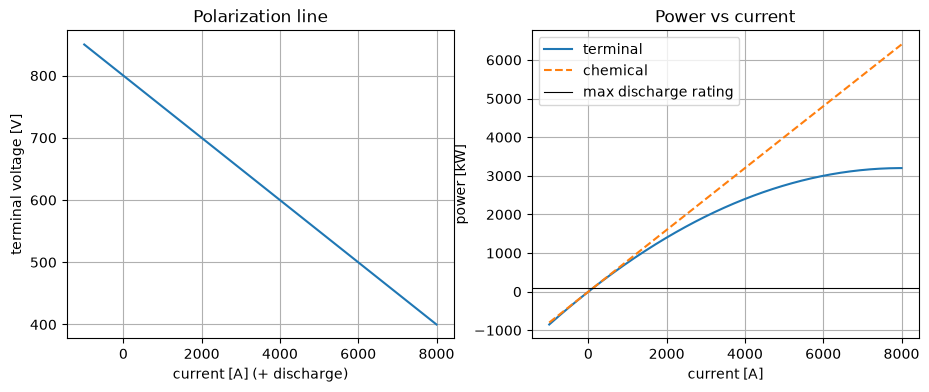

[PASS] battery: terminal power peaks near V_oc/(2R)


In [6]:
current_A = np.linspace(-1000, 8000, 400)
sweep = battery.evaluate(current_A, 0.9)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4))
ax1.plot(current_A, sweep.voltage_V)
ax1.set(xlabel="current [A] (+ discharge)", ylabel="terminal voltage [V]", title="Polarization line")
ax2.plot(current_A, sweep.power_electric_W / 1e3, label="terminal")
ax2.plot(current_A, sweep.power_chemical_W / 1e3, "--", label="chemical")
ax2.axhline(battery.max_discharge_power_W / 1e3, color="k", lw=0.8, label="max discharge rating")
ax2.set(xlabel="current [A]", ylabel="power [kW]", title="Power vs current")
ax2.legend()
plt.show()

# Terminal power peaks at I = V_oc / (2R) (matched load), giving V_oc^2 / (4R).
current_peak_A = current_A[np.argmax(sweep.power_electric_W)]
check("battery: terminal power peaks near V_oc/(2R)",
      abs(current_peak_A - 800 / (2 * 0.05)) < (current_A[1] - current_A[0]))

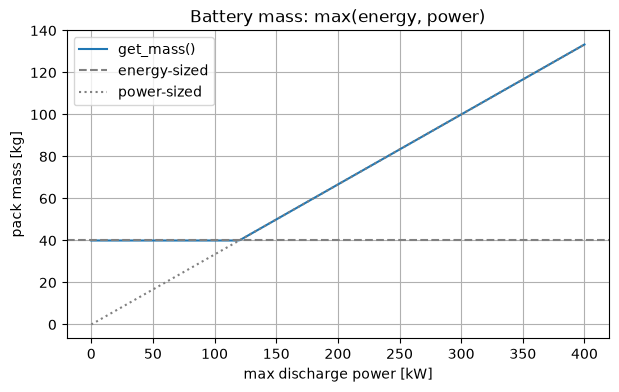

[PASS] battery: default mass is energy-sized (40 kg)
[PASS] battery: 300 kW discharge rating -> power-sized 100 kg
[PASS] battery: 600 kW charge rating -> power-sized 200 kg


In [7]:
# Mass sizing: energy-sized vs power-sized pack.
power_W = np.linspace(0, 400000, 200)
mass_kg = Battery(max_discharge_power_W=power_W).get_mass()
fig, ax = plt.subplots()
ax.plot(power_W / 1e3, mass_kg, label="get_mass()")
ax.axhline(battery.energy_capacity_J / battery.specific_energy_J_kg, ls="--", color="gray", label="energy-sized")
ax.plot(power_W / 1e3, power_W / battery.specific_power_W_kg, ls=":", color="gray", label="power-sized")
ax.set(xlabel="max discharge power [kW]", ylabel="pack mass [kg]", title="Battery mass: max(energy, power)")
ax.legend()
plt.show()

check("battery: default mass is energy-sized (40 kg)", Battery().get_mass() == 40)
check("battery: 300 kW discharge rating -> power-sized 100 kg", Battery(max_discharge_power_W=300000).get_mass() == 100)
check("battery: 600 kW charge rating -> power-sized 200 kg", Battery(max_charge_power_W=600000).get_mass() == 200)

## 4. Turboshaft

Constant thermal efficiency, no altitude lapse or idle:
$\dot m_f = P_s / (\eta_{th}\,\text{LHV})$.

TurboshaftResult(power_shaft_W=100000, fuel_flow_kg_s=0.007751937984496125, power_loss_W=233333.33333333337)
BSFC = 279.1 g/kWh
[PASS] turboshaft: fuel energy * efficiency = shaft power
[PASS] turboshaft: loss + shaft = fuel power
[PASS] turboshaft: zero power -> zero fuel
[PASS] turboshaft: higher efficiency -> less fuel
[PASS] turboshaft: mass = rated power / specific power


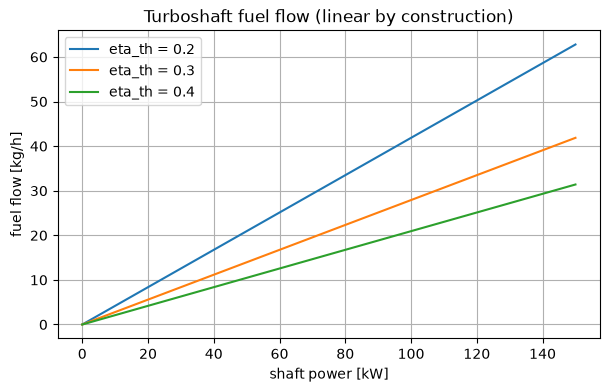

In [8]:
engine = SimpleTurboshaft()
e = engine.evaluate(100000)
print(e)
print(f"BSFC = {e.fuel_flow_kg_s / 100000 * 3.6e9:.1f} g/kWh")

check("turboshaft: fuel energy * efficiency = shaft power",
      close(e.fuel_flow_kg_s * engine.fuel_lower_heating_value_J_kg * engine.thermal_efficiency, 100000))
check("turboshaft: loss + shaft = fuel power",
      close(e.power_loss_W + e.power_shaft_W, e.fuel_flow_kg_s * engine.fuel_lower_heating_value_J_kg))
check("turboshaft: zero power -> zero fuel", engine.evaluate(0).fuel_flow_kg_s == 0)
check("turboshaft: higher efficiency -> less fuel",
      SimpleTurboshaft(thermal_efficiency=0.4).evaluate(100000).fuel_flow_kg_s < e.fuel_flow_kg_s)
check("turboshaft: mass = rated power / specific power", engine.get_mass() == 75)

power_W = np.linspace(0, engine.power_rated_W, 50)
fig, ax = plt.subplots()
for eta in (0.2, 0.3, 0.4):
    ax.plot(power_W / 1e3, SimpleTurboshaft(thermal_efficiency=eta).evaluate(power_W).fuel_flow_kg_s * 3600,
            label=f"eta_th = {eta}")
ax.set(xlabel="shaft power [kW]", ylabel="fuel flow [kg/h]", title="Turboshaft fuel flow (linear by construction)")
ax.legend()
plt.show()

## 5. Gearbox

`reduction_ratio` = input speed / output speed. Loss is taken from torque so
$P_{out} = \omega_{out} Q_{out}$ holds exactly.

In [9]:
gear = Gearbox()
gb = gear.evaluate(400, 200)
print(gb)

check("gearbox: output speed = input / ratio", gb.speed_output_rad_s == 100)
check("gearbox: output torque = input * ratio * efficiency", close(gb.torque_output_Nm, 200 * 4 * 0.97))
check("gearbox: P_out = speed_out * torque_out", close(gb.power_output_W, gb.speed_output_rad_s * gb.torque_output_Nm))
check("gearbox: P_in = P_out + P_loss", close(gb.power_input_W, gb.power_output_W + gb.power_loss_W))
t = Gearbox(reduction_ratio=1, efficiency=1).evaluate(400, 200)
check("gearbox: 1:1 lossless is transparent",
      t.speed_output_rad_s == 400 and t.torque_output_Nm == 200 and t.power_loss_W == 0)
check("gearbox: lower efficiency -> more loss",
      Gearbox(efficiency=0.9).evaluate(400, 200).power_loss_W > Gearbox(efficiency=0.99).evaluate(400, 200).power_loss_W)
check("gearbox: mass = rated power / specific power", gear.get_mass() == 10)

GearboxResult(speed_output_rad_s=100.0, torque_output_Nm=776.0, power_input_W=80000, power_output_W=77600.0, power_loss_W=2400.0000000000023)
[PASS] gearbox: output speed = input / ratio
[PASS] gearbox: output torque = input * ratio * efficiency
[PASS] gearbox: P_out = speed_out * torque_out
[PASS] gearbox: P_in = P_out + P_loss
[PASS] gearbox: 1:1 lossless is transparent
[PASS] gearbox: lower efficiency -> more loss
[PASS] gearbox: mass = rated power / specific power


## 6. Actuator-disk propulsor

Axial momentum theory, normal working state. Two modes:

* **Thrust mode** — closed-form induced velocity (rationalized root), returns shaft power.
* **Power mode** — caller supplies shaft power *and* induced velocity; the component
  returns `power_residual_W`, which the caller drives to zero in `asb.Opti`.

In [10]:
atmosphere = asb.Atmosphere(altitude=0)
rho_kg_m3 = atmosphere.density()
rotor = ActuatorDiskPropulsor()
h = rotor.evaluate(0, atmosphere, thrust_N=5000)
print(h)

ideal_rotor = ActuatorDiskPropulsor(coefficient_of_performance=1)
check("propulsor: ideal hover P = T^1.5 / sqrt(2 rho A)",
      close(ideal_rotor.evaluate(0, atmosphere, thrust_N=5000).shaft_power_W,
            5000**1.5 / np.sqrt(2 * rho_kg_m3 * rotor.area_disk_m2)))
check("propulsor: hover induced velocity = sqrt(T / (2 rho A))",
      close(h.induced_velocity_m_s, np.sqrt(5000 / (2 * rho_kg_m3 * rotor.area_disk_m2))))
for v in (0, 50):
    check(f"propulsor: zero thrust at V={v} -> zero power and vi",
          rotor.evaluate(v, atmosphere, thrust_N=0).shaft_power_W == 0
          and rotor.evaluate(v, atmosphere, thrust_N=0).induced_velocity_m_s == 0)

fwd = rotor.evaluate(20, atmosphere, thrust_N=5000)
inv = rotor.evaluate(20, atmosphere, shaft_power_W=fwd.shaft_power_W, induced_velocity_m_s=fwd.induced_velocity_m_s)
check("propulsor: thrust -> power -> thrust round trip", close(inv.thrust_N, 5000, rel=1e-9))
check("propulsor: round-trip power residual ~ 0", abs(inv.power_residual_W) < 1e-6)

for kwargs in ({"shaft_power_W": 1e5}, {"thrust_N": 5000, "induced_velocity_m_s": 10}):
    try:
        rotor.evaluate(0, atmosphere, **kwargs)
        raised = False
    except ValueError:
        raised = True
    check(f"propulsor: invalid mode {sorted(kwargs)} raises ValueError", raised)

PropulsorResult(thrust_N=5000, shaft_power_W=np.float64(89285.74504783793), induced_velocity_m_s=np.float64(14.285719207654068), power_residual_W=0.0)
[PASS] propulsor: ideal hover P = T^1.5 / sqrt(2 rho A)
[PASS] propulsor: hover induced velocity = sqrt(T / (2 rho A))
[PASS] propulsor: zero thrust at V=0 -> zero power and vi
[PASS] propulsor: zero thrust at V=50 -> zero power and vi
[PASS] propulsor: thrust -> power -> thrust round trip
[PASS] propulsor: round-trip power residual ~ 0
[PASS] propulsor: invalid mode ['shaft_power_W'] raises ValueError
[PASS] propulsor: invalid mode ['induced_velocity_m_s', 'thrust_N'] raises ValueError


C:\Users\alexa\Documents\Chasing Amber\halo\.venv\Lib\site-packages\aerosandbox\library\propulsion_propeller.py:39: RuntimeWarning: divide by zero encountered in divide
  * (np.sqrt(thrust_force / (area_propulsive * airspeed**2 * rho / 2) + 1) + 1)
C:\Users\alexa\Documents\Chasing Amber\halo\.venv\Lib\site-packages\aerosandbox\library\propulsion_propeller.py:36: RuntimeWarning: invalid value encountered in multiply
  0.5


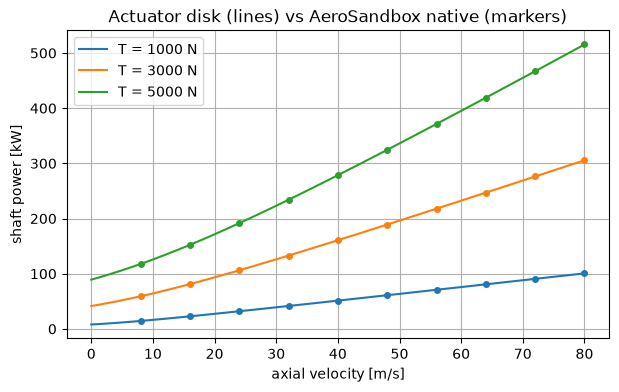

max relative error vs native: 0.00e+00
[PASS] propulsor: matches AeroSandbox native within 1e-9


In [11]:
# Agreement with AeroSandbox's native momentum-theory function across airspeed and thrust.
velocity_m_s = np.linspace(0, 80, 81)
fig, ax = plt.subplots()
max_rel_error = 0.0
for thrust in (1000, 3000, 5000):
    ours = rotor.evaluate(velocity_m_s, atmosphere, thrust_N=thrust).shaft_power_W
    native = propeller_shaft_power_from_thrust(thrust, rotor.area_disk_m2, velocity_m_s, rho_kg_m3, 0.8)
    max_rel_error = max(max_rel_error, float(np.max(np.abs(ours / native - 1))))
    line, = ax.plot(velocity_m_s, ours / 1e3, label=f"T = {thrust} N")
    ax.plot(velocity_m_s[::8], native[::8] / 1e3, "o", color=line.get_color(), ms=4)
ax.set(xlabel="axial velocity [m/s]", ylabel="shaft power [kW]",
       title="Actuator disk (lines) vs AeroSandbox native (markers)")
ax.legend()
plt.show()
print(f"max relative error vs native: {max_rel_error:.2e}")
check("propulsor: matches AeroSandbox native within 1e-9", max_rel_error < 1e-9)

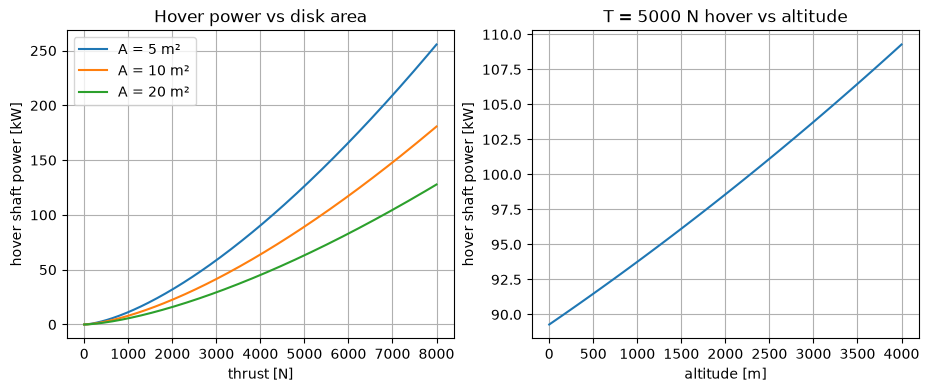

[PASS] propulsor: larger disk -> less hover power
[PASS] propulsor: higher altitude -> more hover power
[PASS] propulsor: better FoM -> less power


In [12]:
# Trends: disk loading and density altitude.
thrust_N = np.linspace(0, 8000, 200)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4))
for area in (5, 10, 20):
    ax1.plot(thrust_N, ActuatorDiskPropulsor(area_disk_m2=area).evaluate(0, atmosphere, thrust_N=thrust_N).shaft_power_W / 1e3,
             label=f"A = {area} m²")
ax1.set(xlabel="thrust [N]", ylabel="hover shaft power [kW]", title="Hover power vs disk area")
ax1.legend()
altitude_m = np.linspace(0, 4000, 50)
hover_W = [rotor.evaluate(0, asb.Atmosphere(altitude=a), thrust_N=5000).shaft_power_W for a in altitude_m]
ax2.plot(altitude_m, np.array(hover_W) / 1e3)
ax2.set(xlabel="altitude [m]", ylabel="hover shaft power [kW]", title="T = 5000 N hover vs altitude")
plt.show()

check("propulsor: larger disk -> less hover power",
      ActuatorDiskPropulsor(area_disk_m2=20).evaluate(0, atmosphere, thrust_N=5000).shaft_power_W < h.shaft_power_W)
check("propulsor: higher altitude -> more hover power", np.all(np.diff(hover_W) > 0))
check("propulsor: better FoM -> less power", ideal_rotor.evaluate(0, atmosphere, thrust_N=5000).shaft_power_W < h.shaft_power_W)

In [13]:
# High axial speed: the rationalized root stays accurate where the naive form cancels.
velocity_m_s, thrust_N = 1e6, 1.0
vi_rationalized = rotor.evaluate(velocity_m_s, atmosphere, thrust_N=thrust_N).induced_velocity_m_s
vi_naive = 0.5 * (-velocity_m_s + np.sqrt(velocity_m_s**2 + 2 * thrust_N / (rho_kg_m3 * rotor.area_disk_m2)))
vi_asymptotic = thrust_N / (2 * rho_kg_m3 * rotor.area_disk_m2 * velocity_m_s)
print(f"rationalized {vi_rationalized:.6e}, naive {vi_naive:.6e}, asymptotic {vi_asymptotic:.6e}")
check("propulsor: rationalized root matches high-speed asymptote", close(vi_rationalized, vi_asymptotic, rel=1e-6))

rationalized 4.081635e-08, naive 4.080357e-08, asymptotic 4.081635e-08
[PASS] propulsor: rationalized root matches high-speed asymptote


## 7. AeroSandbox / CasADi symbolic compatibility

Every component must accept `opti.variable(...)` inputs and return CasADi `MX`
expressions with no Python branching on symbolic values. This includes the
propulsor's `np.where` zero-thrust guard and the battery's `np.maximum` sizing.

In [14]:
opti = asb.Opti()
speed_rad_s = opti.variable(init_guess=400, lower_bound=1)
torque_Nm = opti.variable(init_guess=200, lower_bound=0)
voltage_V = opti.variable(init_guess=800, lower_bound=1)
current_A = opti.variable(init_guess=100)
soc = opti.variable(init_guess=0.9)
thrust_N = opti.variable(init_guess=5000, lower_bound=1)
altitude_m = opti.variable(init_guess=0)
power_rated_W = opti.variable(init_guess=1e5, lower_bound=1)
opti.subject_to([speed_rad_s == 400, torque_Nm == 200, voltage_V == 800, current_A == 100,
                 soc == 0.9, thrust_N == 5000, altitude_m == 0, power_rated_W == 1e5])

symbolic = {
    "Motor.power_electric_W": (Motor().evaluate(speed_rad_s, torque_Nm, voltage_V).power_electric_W,
                               Motor().evaluate(400, 200, 800).power_electric_W),
    "Generator.power_electric_W": (Generator().evaluate(speed_rad_s, torque_Nm, voltage_V).power_electric_W,
                                   Generator().evaluate(400, 200, 800).power_electric_W),
    "Battery.soc_next": (Battery().evaluate(current_A, soc, 60).soc_next, Battery().evaluate(100, 0.9, 60).soc_next),
    "SimpleTurboshaft.fuel_flow_kg_s": (SimpleTurboshaft().evaluate(speed_rad_s * torque_Nm).fuel_flow_kg_s,
                                        SimpleTurboshaft().evaluate(80000).fuel_flow_kg_s),
    "Gearbox.power_output_W": (Gearbox().evaluate(speed_rad_s, torque_Nm).power_output_W,
                               Gearbox().evaluate(400, 200).power_output_W),
    "ActuatorDiskPropulsor.shaft_power_W": (
        ActuatorDiskPropulsor().evaluate(0, asb.Atmosphere(altitude=altitude_m), thrust_N=thrust_N).shaft_power_W,
        h.shaft_power_W),
    "Motor.get_mass (symbolic rating)": (Motor(power_rated_W=power_rated_W).get_mass(), Motor().get_mass()),
    "Battery.get_mass (symbolic rating)": (Battery(max_discharge_power_W=power_rated_W).get_mass(), Battery().get_mass()),
}
check("symbolic: every expression is casadi.MX", all(isinstance(s, cas.MX) for s, _ in symbolic.values()))
solution = opti.solve(verbose=False)
for name, (expression, numeric) in symbolic.items():
    value = float(solution.value(expression))
    check(f"symbolic: {name} = {value:.6g} matches numeric", close(value, numeric, rel=1e-7, abs_=1e-9))

[PASS] symbolic: every expression is casadi.MX
[PASS] symbolic: Motor.power_electric_W = 80960 matches numeric
[PASS] symbolic: Generator.power_electric_W = 79040 matches numeric
[PASS] symbolic: Battery.soc_next = 0.766667 matches numeric
[PASS] symbolic: SimpleTurboshaft.fuel_flow_kg_s = 0.00620155 matches numeric
[PASS] symbolic: Gearbox.power_output_W = 77600 matches numeric
[PASS] symbolic: ActuatorDiskPropulsor.shaft_power_W = 89285.7 matches numeric
[PASS] symbolic: Motor.get_mass (symbolic rating) = 20 matches numeric
[PASS] symbolic: Battery.get_mass (symbolic rating) = 40 matches numeric


C:\Users\alexa\Documents\Chasing Amber\halo\.venv\Lib\site-packages\casadi\casadi.py:913: FutureWarning: 
casadi: a numpy function was called on a casadi value (issue #2959).
This used legacy casadi 3.7.2 behaviour, where the result type follows
the input:
  - a numeric input (DM)       -> a plain numpy array
  - a symbolic input (SX / MX) -> a casadi value, or an error if the
                                  function has no casadi equivalent

For a shape-correct, type-preserving result, opt in to the
casadi-aware numpy support:

    try:
        ca.GlobalOptions.setNumpyMode(1)
    except AttributeError:
        pass

Or use setNumpyMode(-1) to keep legacy behaviour silently.
Shown once; run python with -W always to see every occurrence.

  _w.warn(_NUMPY_LEGACY_NOTICE, FutureWarning)


## 8. Coupled series-hybrid reference point

`examples/series_hybrid_point_explicit.py` couples all six components at one hover point
(5000 N, 20 % battery share) with caller-owned `asb.Opti` variables and
constraints. The propulsor runs in power mode, so inverse momentum theory is
solved by IPOPT, not inside the component.

In [15]:
reference = solve_reference_point()
for field, value in reference.__dict__.items():
    print(f"{field:>24s} = {value:.6g}")

check("coupled: thrust = 5000 N", close(reference.thrust_N, 5000, rel=1e-6))
check("coupled: bus power residual ~ 0", abs(reference.bus_power_residual_W) < 1e-4)
check("coupled: rotor power residual ~ 0", abs(reference.rotor_power_residual_W) < 1e-4)
check("coupled: shaft power positive and within rotor rating", 0 < reference.shaft_power_W < 1e5)
check("coupled: battery discharging, engine burning fuel",
      reference.battery_power_W > 0 and reference.fuel_flow_kg_s > 0)
check("coupled: rotor shaft power equals thrust-mode prediction",
      close(reference.shaft_power_W, h.shaft_power_W, rel=1e-6))

                thrust_N = 5000
           shaft_power_W = 89285.7
         battery_power_W = 18653.2
          fuel_flow_kg_s = 0.00585157
    bus_power_residual_W = -4.58676e-08
  rotor_power_residual_W = -9.36998e-07
[PASS] coupled: thrust = 5000 N
[PASS] coupled: bus power residual ~ 0
[PASS] coupled: rotor power residual ~ 0
[PASS] coupled: shaft power positive and within rotor rating
[PASS] coupled: battery discharging, engine burning fuel
[PASS] coupled: rotor shaft power equals thrust-mode prediction


### Hybridization sweep

A notebook-local copy of the reference coupling with the battery share and
thrust exposed, to confirm the coupled trends: more battery share means less
fuel flow at the same thrust, and fuel flow at a fixed share rises with thrust. At 100 % battery share the
generator still spins unloaded, so a small thrust-independent no-load fuel flow remains.
This is exploratory and does not change the example.

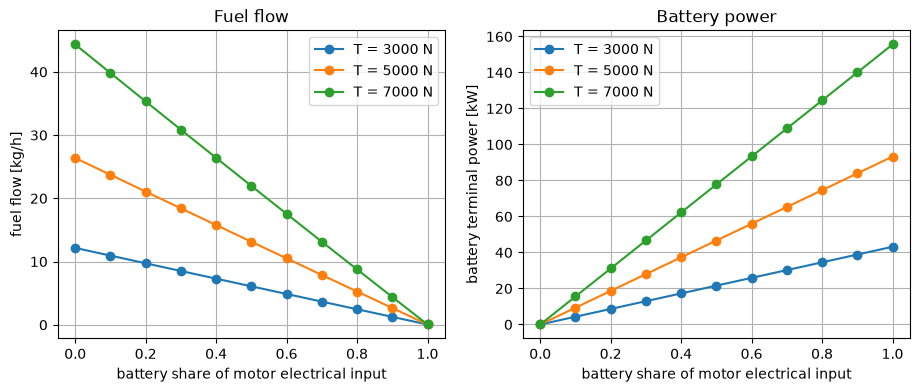

[PASS] sweep: fuel flow falls monotonically with battery share
[PASS] sweep: all-electric point burns only generator no-load fuel, independent of thrust
[PASS] sweep: fuel flow rises with thrust
[PASS] sweep: 20% point reproduces the example


In [16]:
def solve_point(hybridization_electric, thrust_req_N):
    opti = asb.Opti()
    speed_motor_rad_s = 400.0
    torque_motor_Nm = opti.variable(init_guess=200, lower_bound=0)
    torque_generator_Nm = opti.variable(init_guess=200, lower_bound=0)
    current_battery_A = opti.variable(init_guess=20)
    induced_velocity_m_s = opti.variable(init_guess=10, lower_bound=0)
    pack = Battery().evaluate(current_battery_A, soc=0.9)
    motor = Motor().evaluate(speed_motor_rad_s, torque_motor_Nm, pack.voltage_V)
    generator = Generator().evaluate(400, torque_generator_Nm, pack.voltage_V)
    engine = SimpleTurboshaft().evaluate(generator.power_shaft_W)
    gear = Gearbox().evaluate(speed_motor_rad_s, torque_motor_Nm)
    rotor = ActuatorDiskPropulsor().evaluate(0, asb.Atmosphere(altitude=0), shaft_power_W=gear.power_output_W,
                                             induced_velocity_m_s=induced_velocity_m_s)
    opti.subject_to([
        rotor.power_residual_W == 0,
        rotor.thrust_N == thrust_req_N,
        pack.power_electric_W == hybridization_electric * motor.power_electric_W,
        generator.power_electric_W + pack.power_electric_W == motor.power_electric_W,
        generator.power_electric_W >= 0,
    ])
    sol = opti.solve(verbose=False)
    return (sol.value(engine.fuel_flow_kg_s), sol.value(pack.power_electric_W), sol.value(motor.power_electric_W))

hybridization = np.linspace(0, 1, 11)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4))
fuel_by_thrust = {}
for thrust in (3000, 5000, 7000):
    results = np.array([solve_point(x, thrust) for x in hybridization])
    fuel_by_thrust[thrust] = results[:, 0]
    ax1.plot(hybridization, results[:, 0] * 3600, "o-", label=f"T = {thrust} N")
    ax2.plot(hybridization, results[:, 1] / 1e3, "o-", label=f"T = {thrust} N")
ax1.set(xlabel="battery share of motor electrical input", ylabel="fuel flow [kg/h]", title="Fuel flow")
ax2.set(xlabel="battery share of motor electrical input", ylabel="battery terminal power [kW]", title="Battery power")
ax1.legend(); ax2.legend()
plt.show()

check("sweep: fuel flow falls monotonically with battery share",
      all(np.all(np.diff(f) < 0) for f in fuel_by_thrust.values()))
# At 100% battery share the generator still spins at 400 rad/s with zero electrical output,
# so the engine supplies only its no-load loss: w*Q = k_Q Q^2 + k_w w^2 (smaller root).
k, speed_generator_rad_s = Generator().loss_model, 400.0
torque_no_load_Nm = (speed_generator_rad_s - np.sqrt(speed_generator_rad_s**2 - 4 * k.torque_loss_W_Nm2
                     * k.speed_loss_W_s2_rad2 * speed_generator_rad_s**2)) / (2 * k.torque_loss_W_Nm2)
fuel_no_load_kg_s = SimpleTurboshaft().evaluate(speed_generator_rad_s * torque_no_load_Nm).fuel_flow_kg_s
check("sweep: all-electric point burns only generator no-load fuel, independent of thrust",
      all(close(f[-1], fuel_no_load_kg_s, rel=1e-6) for f in fuel_by_thrust.values()))
check("sweep: fuel flow rises with thrust",
      np.all(fuel_by_thrust[3000][:-1] < fuel_by_thrust[5000][:-1]) and np.all(fuel_by_thrust[5000][:-1] < fuel_by_thrust[7000][:-1]))
check("sweep: 20% point reproduces the example", close(solve_point(0.2, 5000)[0], reference.fuel_flow_kg_s, rel=1e-6))

## 9. Summary and unit test suite

In [17]:
failed = [name for name, passed in check_log if not passed]
print(f"{len(check_log) - len(failed)} / {len(check_log)} notebook checks passed")
for name in failed:
    print("  FAIL:", name)

71 / 71 notebook checks passed


In [18]:
import os, unittest

os.chdir(repo_root)
suite = unittest.defaultTestLoader.discover(str(repo_root / "tests"), top_level_dir=str(repo_root / "tests"))
test_result = unittest.TextTestRunner(verbosity=1, stream=sys.stdout).run(suite)
assert test_result.wasSuccessful() and not failed, "Verification failed"

.

.

.

.

.

...

.

.

.

----------------------------------------------------------------------
Ran 77 tests in 0.228s

OK


C:\Users\alexa\Documents\Chasing Amber\halo\.venv\Lib\site-packages\casadi\casadi.py:913: FutureWarning: 
casadi: a numpy function was called on a casadi value (issue #2959).
This used legacy casadi 3.7.2 behaviour, where the result type follows
the input:
  - a numeric input (DM)       -> a plain numpy array
  - a symbolic input (SX / MX) -> a casadi value, or an error if the
                                  function has no casadi equivalent

For a shape-correct, type-preserving result, opt in to the
casadi-aware numpy support:

    try:
        ca.GlobalOptions.setNumpyMode(1)
    except AttributeError:
        pass

Or use setNumpyMode(-1) to keep legacy behaviour silently.
Shown once; run python with -W always to see every occurrence.

  _w.warn(_NUMPY_LEGACY_NOTICE, FutureWarning)
